In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()
# If you're running the notebook from a subfolder, walk up until we find "data"
while not (PROJECT_ROOT / "data").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
import os
import time
import requests
import json
import numpy as np
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt

from data.providers.binance import BinanceProvider
from data.providers.coingecko import CoingeckoProvider

In [3]:
url = "https://api.coingecko.com/api/v3/coins/markets"
params = {
    "vs_currency": "usd",
    "order": "market_cap_desc",
    "per_page": 100,
    "page": 1,
    "sparkline": False,
}

response = requests.get(url, params=params)
coins = response.json()

print(f"{'#':<4} {'Symbol':<8} {'Name':<22} {'Price':>12} {'Market Cap':>18} {'24h Vol':>16} {'24h %':>8}")
print("-" * 92)

for i, c in enumerate(coins, 1):
    price = c['current_price'] or 0
    mcap = c['market_cap'] or 0
    vol = c['total_volume'] or 0
    change = c['price_change_percentage_24h'] or 0

    print(
        f"{i:<4} {c['symbol'].upper():<8} {c['name'][:20]:<22} "
        f"${price:>11,.2f} ${mcap:>16,.0f} "
        f"${vol:>14,.0f} "
        f"{change:>+7.2f}%"
    )

#    Symbol   Name                          Price         Market Cap          24h Vol    24h %
--------------------------------------------------------------------------------------------
1    BTC      Bitcoin                $  64,401.00 $1,290,604,672,583 $18,597,639,551   +0.97%
2    ETH      Ethereum               $   1,675.40 $ 202,170,902,956 $ 5,317,626,130   -0.01%
3    USDT     Tether                 $       1.00 $ 186,488,750,384 $33,629,643,909   +0.01%
4    BNB      BNB                    $     610.35 $  82,250,012,287 $   440,487,383   +1.23%
5    USDC     USDC                   $       1.00 $  74,854,743,738 $ 5,561,233,853   -0.00%
6    XRP      XRP                    $       1.15 $  71,089,774,154 $   999,770,910   +0.41%
7    SOL      Solana                 $      68.17 $  39,519,600,711 $ 1,625,931,491   +1.22%
8    TRX      TRON                   $       0.32 $  29,992,144,783 $   409,418,731   +0.31%
9    FIGR_HELOC Figure Heloc           $       1.02 $  19,162,760,7

In [4]:
tickers = requests.get("https://api.binance.com/api/v3/ticker/24hr").json()
binance_map = {t['symbol']: t for t in tickers if t['symbol'].endswith('USDT')}
f'Number of coins: {len(binance_map)}'

'Number of coins: 670'

In [5]:
matched = []
unmatched = []

for c in coins:
    symbol = c['symbol'].upper() + "USDT"
    if symbol in binance_map:
        matched.append({
            "coingecko_symbol": c['symbol'],
            "binance_symbol": symbol,
            "coingecko": c,
            "binance_ticker": binance_map[symbol],
        })
    else:
        unmatched.append(symbol)
    if len(matched) >= 100:
        break

f'Matched coins: {len(matched)}'

'Matched coins: 58'

In [6]:
klines = requests.get("https://api.binance.com/api/v3/klines", params={
            "symbol": 'BTCUSDT',
            "interval": "1d",
            "limit": 30,
        }).json()

for kline in klines:
    time = kline[0]
    print(time)
    print(pd.to_datetime(time, unit = 'ms'))
    print(datetime.fromtimestamp(kline[0] / 1000).strftime("%Y-%m-%d"))
    break

1778889600000
2026-05-16 00:00:00
2026-05-16


In [7]:
datetime.fromtimestamp(1776902400000 / 1000)

datetime.datetime(2026, 4, 23, 2, 0)

In [8]:
x = pd.Series([1, 2, 3, 4, 5])
x[:3].mean()

np.float64(2.0)

In [9]:
def relative_volume(volume, short = 5, long = 30):
    return volume[:short].mean() / volume[:long].mean()

>To transform time to datetime you must do `pd.to_datetime(time, unit='ms')`

In [10]:
for i, m in enumerate(matched):
    symbol = m['binance_symbol']
    klines = requests.get("https://api.binance.com/api/v3/klines", params={
        "symbol": symbol,
        "interval": "1d",
        "limit": 30,
    }).json()

    daily = []
    for k in klines:
        daily.append({
            "date": pd.to_datetime(k[0], unit = 'ms'),
            "open": float(k[1]),
            "high": float(k[2]),
            "low": float(k[3]),
            "close": float(k[4]),
            "volume": float(k[5]),           # base asset volume
            "volume_usdt": float(k[7]),       # quote volume in USDT
            "trades": int(k[8]),
        })

    m['daily_klines'] = daily

    # Volume change: compare day 1 vs day 5
    if len(daily) >= 2:
        vol_series = {day['date']: day['volume_usdt'] for day in daily}
        vol_series = pd.Series(vol_series)
        vol_series = vol_series.iloc[::-1]
        m['rvol'] = relative_volume(vol_series)
    else:
        print('Error calculating RVOL')
        m['rvol'] = 0
    
    if (i + 1) % 20 == 0:
        print(f"Fetched {i + 1}/{len(matched)}...")

Fetched 20/58...
Fetched 40/58...


In [11]:
STABLECOINS = {
    "USDT", "USDC", "BUSD", "DAI", "TUSD", "USDP", "USDD", "GUSD",
    "FRAX", "LUSD", "SUSD", "CRVUSD", "PYUSD", "FDUSD", "USDE",
    "EURC", "EURT", "GHO", "ALUSD", "MIM", "UST", "USTC",
    "USDB", "USD0", "USDS",
}

# filtered = [c for c in coins if c['symbol'].upper() not in STABLECOINS]
filtered = [m for m in matched if m['coingecko_symbol'].upper() not in STABLECOINS]

In [12]:
assets = []

print(f"\n{'#':<4} {'Symbol':<10} {'Mkt Cap':>14} {'Price':>12} {'5d Vol Chg':>11}")
print("-" * 55)

for i, m in enumerate(filtered, 1):
    c = m['coingecko']
    assets.append({
        "#": i,
        "Symbol": c['symbol'].upper(),
        "Mkt Cap": c['market_cap'],
        "Price": c['current_price'],
        "RVOL": m['rvol']
    })

    print(
        f"{i:<4} {c['symbol'].upper():<10} "
        f"${c['market_cap']:>12,.0f} "
        f"${c['current_price']:>10,.2f} "
        f"{m['rvol']:>+10.4f}%"
    )

df = pd.DataFrame(assets)


#    Symbol            Mkt Cap        Price  5d Vol Chg
-------------------------------------------------------
1    BTC        $1,290,604,672,583 $ 64,401.00    +0.6433%
2    ETH        $202,170,902,956 $  1,675.40    +0.4853%
3    BNB        $82,250,012,287 $    610.35    +0.4246%
4    XRP        $71,089,774,154 $      1.15    +0.6276%
5    SOL        $39,519,600,711 $     68.17    +0.7264%
6    TRX        $29,992,144,783 $      0.32    +0.6661%
7    DOGE       $13,482,301,269 $      0.09    +0.7262%
8    ZEC        $7,164,426,396 $    427.47    +0.5522%
9    ADA        $6,370,777,725 $      0.17    +0.7236%
10   XMR        $6,350,492,946 $    338.34    +0.4050%
11   XLM        $6,293,107,295 $      0.19    +0.4524%
12   LINK       $5,745,698,194 $      7.90    +0.4584%
13   TON        $4,621,707,030 $      1.73    +0.4852%
14   USD1       $4,368,461,777 $      1.00    +0.7784%
15   BCH        $4,077,413,938 $    203.41    +0.4808%
16   HBAR       $3,428,680,178 $      0.08    +0.44

In [13]:
binance = BinanceProvider()
pairs = binance.get_pairs()

In [14]:
coingecko = CoingeckoProvider()
coins = coingecko.get_top_coins()

In [15]:
stablecoins = coingecko.get_stablecoins()

  Loaded 214 stablecoin symbols (hardcoded + CoinGecko)


In [16]:
STABLECOINS_HARDCODED = {
    "USDT", "USDC", "BUSD", "DAI", "TUSD", "USDP", "USDD", "GUSD",
    "FRAX", "LUSD", "SUSD", "CRVUSD", "PYUSD", "FDUSD", "USDE",
    "EURC", "EURT", "GHO", "ALUSD", "MIM", "UST", "USTC",
    "USDB", "USD0", "USDS", "USDJ", "CUSD", "RSV", "PAX",
}
 
WRAPPED_TOKENS = {
    "WBTC", "WETH", "STETH", "CBETH", "RETH", "WBNB", "WMATIC",
    "WSOL", "WTRX", "HBTC", "RENBTC", "TBTC", "SBTC", "BETH",
    "METH", "MSOL", "BNSOL", "JITOSOL",
}

In [17]:
excluded = set(STABLECOINS_HARDCODED) | WRAPPED_TOKENS | stablecoins
candidates = []
for c in coins:
    sym = c["symbol"].upper()
    if sym in excluded:
        continue
    if sym in pairs:
        candidates.append({
            "symbol": sym,
            "coin_id": c["id"],
            "name": c["name"],
            "rank": c.get("market_cap_rank", 999),
            "binance_symbol": pairs[sym],
        })
    if len(candidates) >= 100:
        break

In [18]:
print(f"  Matched {len(candidates)} coins (filtered stables/wrapped, Binance-listed)")
for i, c in enumerate(candidates[:10], 1):
    print(f"    {i:>3}. {c['symbol']:<8} {c['name']}")
if len(candidates) > 10:
    print(f"    ... and {len(candidates) - 10} more")

  Matched 0 coins (filtered stables/wrapped, Binance-listed)


In [19]:
BINANCE_DAYS = 730
DAYS = 365
CACHE_DIR = "coin_cache"
OUTPUT_DIR = "backtest_data"

In [20]:
os.makedirs(CACHE_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [21]:
def merge_data(binance_data, coingecko_data):
    """Merge Binance volume with CoinGecko market cap by date"""
    cg_map = {}
    if coingecko_data:
        for row in coingecko_data:
            cg_map[row["date"]] = row
 
    merged = []
    for b in binance_data:
        date = b["date"]
        cg = cg_map.get(date, {})
        merged.append({
            "date": date,
            "open": b["open"],
            "high": b["high"],
            "low": b["low"],
            "close": b["close"],
            "volume_base": b["volume_base"],
            "volume_usdt": b["volume_usdt"],
            "trades": b["trades"],
            "market_cap": cg.get("cg_market_cap"),
            "cg_volume": cg.get("cg_volume"),
        })
    return merged

In [22]:
print(f"Fetching historical data ({BINANCE_DAYS}d volume + {DAYS}d market cap)...")
results = []
for i, coin in enumerate(candidates):
    sym = coin["symbol"]
    coin_id = coin["coin_id"]
    cache_file = os.path.join(CACHE_DIR, f"{sym}_{coin_id}.json")

    # Check cache
    if os.path.exists(cache_file):
        with open(cache_file) as f:
            cached = json.load(f)
        results.append(cached)
        print(f"  [{i+1:>3}/{len(candidates)}] {sym:<8} (cached)")
        continue

    print(f"  [{i+1:>3}/{len(candidates)}] {sym:<8} fetching...", end=" ", flush=True)

    # Binance klines
    binance_data = binance.get_klines(coin["binance_symbol"], days=BINANCE_DAYS)
    print(f"Binance: {len(binance_data)}d", end=" ", flush=True)

    # CoinGecko market chart
    time.sleep(7)
    cg_data = coingecko.get_coin_data(coin_id, days=DAYS)
    cg_len = len(cg_data) if cg_data else 0
    print(f"| CoinGecko: {cg_len}d", end=" ", flush=True)

    # Merge
    merged = merge_data(binance_data, cg_data)

    result = {
        "symbol": sym,
        "coin_id": coin_id,
        "name": coin["name"],
        "rank": coin["rank"],
        "merged": merged,
    }

    # Cache
    with open(cache_file, "w") as f:
        json.dump(result, f)

    results.append(result)
    print("✓")

Fetching historical data (730d volume + 365d market cap)...


In [23]:
df = pd.read_csv("backtest_data/_master.csv", parse_dates=["date"])
bt = df[~df['market_cap'].isna()]
volume_df = pd.pivot_table(bt, values='volume_usdt', index='date', columns='symbol')
price_df = pd.pivot_table(bt, values='close', index='date', columns='symbol')
volume_df

symbol,2Z,AAVE,ADA,ALGO,APT,ARB,ASTER,ATOM,AVAX,AXS,...,WLD,WLFI,XAUT,XLM,XPL,XRP,XTZ,ZEC,ZRO,币安人生
date,,,,,,,,,,,,,,,,,,,,,
2025-05-24,NaN,7.621414e+07,5.540998e+07,4.399690e+06,1.332654e+07,1.125895e+07,NaN,6.216916e+06,4.393987e+07,2.342084e+06,...,9.368285e+07,NaN,NaN,8.661560e+06,NaN,1.185756e+08,9.386291e+05,1.772452e+06,6.245692e+06,NaN
2025-05-25,NaN,5.898738e+07,5.987951e+07,4.990341e+06,1.854867e+07,1.221195e+07,NaN,7.473315e+06,3.529042e+07,2.783534e+06,...,5.451591e+07,NaN,NaN,1.142690e+07,NaN,1.876262e+08,9.886939e+05,7.624133e+06,4.892352e+06,NaN
2025-05-26,NaN,5.538730e+07,6.080568e+07,5.768696e+06,1.819124e+07,2.179767e+07,NaN,6.723292e+06,3.948337e+07,2.113150e+06,...,7.077172e+07,NaN,NaN,9.255882e+06,NaN,1.752319e+08,9.368071e+05,7.524661e+06,7.171436e+06,NaN
2025-05-27,NaN,4.694125e+07,6.959419e+07,5.076279e+06,1.871807e+07,2.490309e+07,NaN,9.582279e+06,5.464893e+07,2.698747e+06,...,7.932585e+07,NaN,NaN,1.136681e+07,NaN,2.177019e+08,1.482671e+06,6.366341e+06,5.506790e+06,NaN
2025-05-28,NaN,3.521434e+07,5.648667e+07,4.925346e+06,2.436809e+07,2.710587e+07,NaN,8.309320e+06,4.297977e+07,2.244375e+06,...,6.257854e+07,NaN,NaN,1.330121e+07,NaN,2.272597e+08,2.047013e+06,4.691489e+06,5.346274e+06,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-05-19,4.947722e+05,8.051010e+06,1.948018e+07,4.618629e+06,3.324677e+06,2.175190e+06,4.932854e+06,3.055554e+06,9.536213e+06,2.495249e+06,...,8.459650e+06,3.410884e+06,2.133452e+07,1.103246e+07,2.904085e+06,1.352435e+08,3.752369e+05,1.184165e+08,2.271900e+06,1.927269e+07
2026-05-20,2.861189e+06,1.047395e+07,2.075863e+07,4.255397e+06,3.162404e+06,4.482348e+06,1.943569e+07,1.645985e+06,1.286308e+07,1.471063e+06,...,1.367057e+07,3.075858e+06,1.629845e+07,5.681002e+06,4.659671e+06,9.420712e+07,2.355751e+05,2.280593e+08,1.840368e+06,3.573999e+07
2026-05-21,7.001588e+06,1.129311e+07,2.677901e+07,2.764025e+06,5.946338e+06,6.123499e+06,3.724575e+07,3.300935e+06,2.771812e+07,1.130469e+06,...,2.212035e+07,4.155041e+06,1.185341e+07,5.595088e+06,6.551480e+06,1.069471e+08,4.678876e+05,1.316197e+08,1.914331e+06,7.255174e+06


In [31]:
K = 5
N_COINS = 10
FEE_RATE = 0.001
SHORT_SMA = 3
LONG_SMA = 28

short_sma= volume_df.rolling(SHORT_SMA).mean()
long_sma = volume_df.rolling(LONG_SMA).mean()
rvol = short_sma / long_sma

In [32]:
signal = {}

for i, row in rvol.iterrows():

    clean = row.dropna()
    
    if clean.notna().sum() >= N_COINS * 2:
        top = clean.nlargest(N_COINS)
        bot = clean.nsmallest(N_COINS)

        signal[i] = {
            'top': list(top.index),
            'bot': list(bot.index)
        }

In [33]:
rts = price_df.pct_change().shift(-1)
rts

symbol,2Z,AAVE,ADA,ALGO,APT,ARB,ASTER,ATOM,AVAX,AXS,...,WLD,WLFI,XAUT,XLM,XPL,XRP,XTZ,ZEC,ZRO,币安人生
date,,,,,,,,,,,,,,,,,,,,,
2025-05-24,NaN,0.028375,0.017544,0.003623,-0.008845,0.004335,NaN,0.015907,0.021341,0.000352,...,0.011388,NaN,NaN,0.006294,NaN,0.004892,0.005685,0.102849,0.015736,NaN
2025-05-25,NaN,-0.006536,0.000790,-0.012184,0.005316,-0.004062,NaN,-0.002923,-0.016205,-0.011248,...,-0.038705,NaN,NaN,-0.006949,NaN,-0.013409,-0.013243,-0.004580,-0.002951,NaN
2025-05-26,NaN,0.015139,-0.002762,0.014162,0.013975,0.024471,NaN,-0.004606,0.013437,0.021330,...,0.027086,NaN,NaN,0.004549,NaN,0.002813,0.017185,-0.044911,0.005179,NaN
2025-05-27,NaN,-0.024229,-0.014111,-0.020270,0.004656,0.019408,NaN,0.019142,0.009410,0.002436,...,-0.032787,NaN,NaN,-0.006270,NaN,-0.018387,0.036846,0.026787,-0.004049,NaN
2025-05-28,NaN,-0.056568,-0.034109,-0.036322,-0.043382,-0.032463,NaN,-0.047678,-0.057203,-0.023264,...,-0.034635,NaN,NaN,-0.022783,NaN,-0.013191,-0.043451,-0.001502,-0.041390,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-05-19,0.167322,0.007206,0.004029,0.043478,0.021505,-0.029956,0.055385,-0.024008,0.020637,0.030848,...,0.039413,0.045000,0.010527,0.002089,0.068543,0.004113,0.021863,0.173456,0.026395,0.055182
2026-05-20,0.086831,0.001136,0.006019,-0.022109,0.025263,0.026340,0.010204,0.030120,0.016670,0.000000,...,0.083501,-0.004785,-0.002509,0.019458,0.028637,0.004901,0.025791,-0.013496,0.005878,0.003865
2026-05-21,-0.056599,-0.022573,-0.033107,-0.028696,-0.034908,-0.037168,-0.033189,0.008772,-0.031630,-0.044888,...,0.007446,-0.035256,-0.006895,-0.021813,-0.084633,-0.028677,-0.043429,-0.122778,-0.059898,-0.040091


In [27]:
fee_rate = 0.001
strat = {}
strat_net = {}
strat_net_long = {}

prev_weights = pd.Series(0, index=rts.columns)
prev_weights_long = pd.Series(0, index=rts.columns)

for i, row in rts.iterrows():
    selection = signal.get(i, None)
    if selection is not None:
        long = row[selection['top']].mean()
        short = -row[selection['bot']].mean()

        weights = pd.Series(0.0, index=row.index)
        weights_long = weights.copy()

        weights_long[selection['top']] =  1 / len(selection['top'])
        weights[selection['top']] =  1 / len(selection['top'])
        weights[selection['bot']] = -1 / len(selection['bot'])
        
        gross_return = (weights * row).sum()
        turnover = (weights - prev_weights).abs().sum()
        transaction_cost = turnover * FEE_RATE
        net_return = gross_return - transaction_cost

        gross_return_long = (weights_long * row).sum()
        turnover_long = (weights_long - prev_weights_long).abs().sum()
        transaction_cost_long = turnover_long * FEE_RATE
        net_return_long = gross_return_long - transaction_cost_long
        
        portfolio = long + short
        
        strat[i] = portfolio
        strat_net[i] = net_return
        strat_net_long[i] = net_return_long

        prev_weights = weights
        prev_weights_long = weights_long
        
strat = pd.Series(strat)
strat_net = pd.Series(strat_net)
strat_net_long = pd.Series(strat_net_long)

In [36]:
hold_strat = {}
hold_strat_net = {}

active_tranches = {}
prev_weights = pd.Series(0.0, index=rts.columns)

for i, row in rts.iterrows():

    selection = signal.get(i, None)
    if selection is not None:
        w = pd.Series(0.0, index=row.index)
        w[selection['top']] =  1 / len(selection['top'])
        w[selection['bot']] = -1 / len(selection['bot'])
        active_tranches[i] = {'weights': w, 'days_left': K}

    if not active_tranches:
        continue

    combined_weights = pd.Series(0.0, index=row.index)
    for tranche in active_tranches.values():
        combined_weights += tranche['weights'] / K


    gross_return = (combined_weights * row).sum()
    turnover = (combined_weights - prev_weights).abs().sum()
    net_return = gross_return - turnover * fee_rate

    hold_strat[i] = gross_return
    hold_strat_net[i] = net_return

    prev_weights = combined_weights.copy()

    # if len(active_tranches) > 5:
    #     print("Too many tranches")
    # elif len(active_tranches) < 5:
    #     print(f'Observation with {len(active_tranches)} tranches')

    expired = [d for d, t in active_tranches.items() if t['days_left'] == 1]
    for d in expired:
        del active_tranches[d]
    for t in active_tranches.values():
        t['days_left'] -= 1

hold_strat     = pd.Series(hold_strat)
hold_strat_net = pd.Series(hold_strat_net)

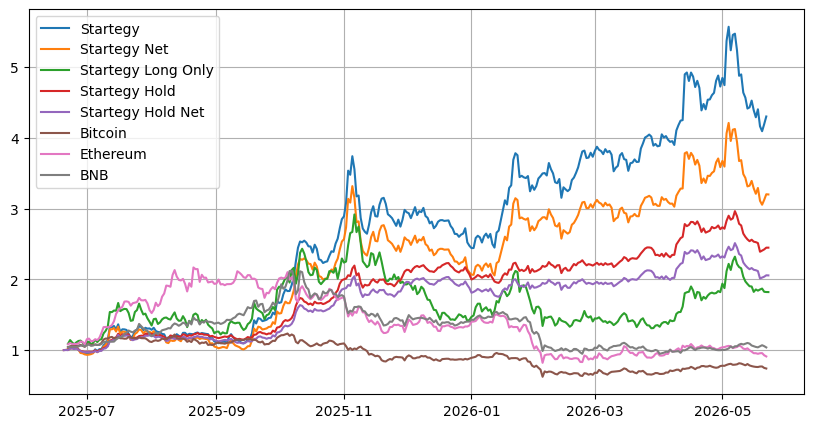

In [37]:
equity = (strat + 1).cumprod()
equity_net = (strat_net + 1).cumprod()
equity_net_long = (strat_net_long + 1).cumprod()
equity_hold = (hold_strat + 1).cumprod()
equity_hold_net = (hold_strat_net + 1).cumprod()

btc = rts['BTC'].reindex(equity.index)
btc = (1 + btc).cumprod()
eth = rts['ETH'].reindex(equity.index)
eth = (1 + eth).cumprod()
bnb = rts['BNB'].reindex(equity.index)
bnb = (1 + bnb).cumprod()

plt.figure(figsize=(10, 5))

plt.plot(equity, label='Startegy')
plt.plot(equity_net, label='Startegy Net')

plt.plot(equity_net_long, label='Startegy Long Only')

plt.plot(equity_hold, label='Startegy Hold')
plt.plot(equity_hold_net, label='Startegy Hold Net')

plt.plot(btc, label='Bitcoin')
plt.plot(eth, label='Ethereum')
plt.plot(bnb, label='BNB')

plt.legend()
plt.grid()
plt.show()

In [50]:
futures_spot_list = binance.get_futures_w_spot()

In [51]:
futures = []

for symbol in futures_spot_list['futures_symbol']:
    resp = binance.get_klines(symbol, source='FUTURES', days=365)
    futures.extend(resp)

df_futures = pd.DataFrame(futures)
df_futures

,symbol,date,open,high,low,close,volume_base,volume_usdt,trades
0,0GUSDT,2025-09-17,1.1000,3.2000,1.1000,2.7815,115465580.0,2.480649e+08,2580380
1,0GUSDT,2025-09-18,2.7797,3.6399,2.2071,2.8067,215889475.0,5.704244e+08,5375891
2,0GUSDT,2025-09-19,2.8069,3.0100,2.5226,2.7694,78480860.0,2.181491e+08,5557746
3,0GUSDT,2025-09-20,2.7693,2.8530,2.6100,2.6399,27845564.0,7.623917e+07,1338848
4,0GUSDT,2025-09-21,2.6403,3.6500,2.2538,3.1530,92862895.0,2.732149e+08,2550390
...,...,...,...,...,...,...,...,...,...
123849,币安人生USDT,2026-06-11,0.7117,0.7424,0.6666,0.6684,43780916.0,3.089416e+07,358245
123850,币安人生USDT,2026-06-12,0.6684,0.6970,0.6325,0.6924,42328897.0,2.811264e+07,355097
123851,币安人生USDT,2026-06-13,0.6924,0.7028,0.6653,0.6692,19903702.0,1.349887e+07,206005
123852,币安人生USDT,2026-06-14,0.6692,0.6840,0.6627,0.6627,14987164.0,1.005651e+07,149552


In [52]:
spot = []

for symbol in futures_spot_list['spot_symbol']:
    resp = binance.get_klines(symbol, source='SPOT', days=365)
    spot.extend(resp)

df_spot = pd.DataFrame(spot)
df_spot

,symbol,date,open,high,low,close,volume_base,volume_usdt,trades
0,0GUSDT,2025-09-22,1.0000,7.2600,1.0000,4.8390,69411652.78,3.436885e+08,1204307
1,0GUSDT,2025-09-23,4.8380,7.1800,4.5660,5.8150,52749822.84,3.049379e+08,1340566
2,0GUSDT,2025-09-24,5.8200,5.8950,4.8380,5.0050,19526670.81,1.022588e+08,512620
3,0GUSDT,2025-09-25,5.0060,5.0140,3.6490,3.9170,13281842.95,5.364342e+07,370729
4,0GUSDT,2025-09-26,3.9170,4.4550,3.3410,3.6790,14793109.26,5.669995e+07,317501
...,...,...,...,...,...,...,...,...,...
123204,币安人生USDT,2026-06-11,0.7107,0.7405,0.6665,0.6684,16689680.10,1.175592e+07,86834
123205,币安人生USDT,2026-06-12,0.6688,0.6971,0.6368,0.6925,14752938.60,9.798375e+06,84269
123206,币安人生USDT,2026-06-13,0.6922,0.7026,0.6670,0.6694,6092411.90,4.128518e+06,40457
123207,币安人生USDT,2026-06-14,0.6695,0.6830,0.6635,0.6635,4110033.90,2.755509e+06,29134


In [53]:
futures_spot_list

,base_asset,spot_symbol,futures_symbol
0,0G,0GUSDT,0GUSDT
1,1000CAT,1000CATUSDT,1000CATUSDT
2,1000CHEEMS,1000CHEEMSUSDT,1000CHEEMSUSDT
3,1000SATS,1000SATSUSDT,1000SATSUSDT
4,1INCH,1INCHUSDT,1INCHUSDT
...,...,...,...
359,ZKC,ZKCUSDT,ZKCUSDT
360,ZKP,ZKPUSDT,ZKPUSDT
361,ZRO,ZROUSDT,ZROUSDT
362,ZRX,ZRXUSDT,ZRXUSDT


In [54]:
excluded = set(STABLECOINS_HARDCODED) | WRAPPED_TOKENS | stablecoins
future_candidates = []
for c in coins:
    sym = c["symbol"].upper()
    if sym in excluded:
        continue
    if sym in futures_spot_list['base_asset'].values:
        _, spot, future = futures_spot_list[futures_spot_list['base_asset'] == sym].values[0]
        future_candidates.append({
            "symbol": sym,
            "coin_id": c["id"],
            "name": c["name"],
            "rank": c.get("market_cap_rank", 999),
            "binance_spot": spot,
            "binance_future": future
        })
    if len(future_candidates) >= 100:
        break

In [55]:
spot_filter = [c['binance_spot'] for c in future_candidates]
futuers_filter = [c['binance_future'] for c in future_candidates]
df_spot_filtered = df_spot[df_spot['symbol'].isin(spot_filter)]
df_futures_filtered = df_futures[df_futures['symbol'].isin(futuers_filter)]

In [56]:
spot_volume = pd.pivot_table(df_spot_filtered, values='volume_usdt', index='date', columns='symbol')
spot_px = pd.pivot_table(df_spot_filtered, values='close', index='date', columns='symbol')
future_px = pd.pivot_table(df_futures_filtered, values='close', index='date', columns='symbol')

In [57]:
short_sma= spot_volume.rolling(SHORT_SMA).mean()
long_sma = spot_volume.rolling(LONG_SMA).mean()
rvol = short_sma / long_sma

signal_ext = {}

for i, row in rvol.iterrows():

    clean = row.dropna()
    
    if clean.notna().sum() >= 10:
        top = clean.nlargest(5)
        bot = clean.nsmallest(5)

        signal_ext[i] = {
            'top': list(top.index),
            'bot': list(bot.index)
        }

In [58]:
future_rts = future_px.pct_change().shift(-1)
spot_rts = spot_px.pct_change().shift(-1)
future_rts

/var/folders/vy/wx4s8rtd79n9d9lh1qlpfmh00000gn/T/ipykernel_72191/1298566582.py:2: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  spot_rts = spot_px.pct_change().shift(-1)


symbol,2ZUSDT,AAVEUSDC,ADAUSDC,ALGOUSDT,APEUSDT,APTUSDT,ARBUSDC,ARUSDT,ASTERUSDT,ATOMUSDT,...,WLFIUSDC,XAUTUSDT,XLMUSDT,XMRUSDT,XPLUSDT,XRPUSDC,XTZUSDT,ZECUSDC,ZROUSDT,币安人生USDT
date,,,,,,,,,,,,,,,,,,,,,
2025-06-16,NaN,-0.030789,-0.033640,-0.036953,-0.018267,-0.051223,-0.048038,-0.031696,NaN,-0.029234,...,NaN,NaN,-0.036732,-0.005352,NaN,-0.035433,-0.042705,NaN,-0.050390,NaN
2025-06-17,NaN,-0.028691,-0.008210,0.006494,-0.034446,0.003152,0.012203,-0.022913,NaN,-0.001493,...,NaN,NaN,0.001946,-0.011701,NaN,0.005327,-0.003717,NaN,0.044798,NaN
2025-06-18,NaN,-0.013437,-0.003311,-0.008211,0.003982,-0.015822,-0.018573,0.000558,NaN,0.005733,...,NaN,NaN,-0.011219,-0.015923,NaN,-0.002673,-0.007463,NaN,-0.041401,NaN
2025-06-19,NaN,-0.032524,-0.041196,-0.012419,-0.025381,-0.026202,-0.049137,-0.056920,NaN,-0.027509,...,NaN,NaN,-0.030271,-0.001287,NaN,-0.021161,-0.030075,NaN,-0.051441,NaN
2025-06-20,NaN,-0.051013,-0.036383,-0.027545,-0.056478,-0.025783,-0.040503,-0.040828,NaN,-0.034149,...,NaN,NaN,-0.019888,-0.005057,NaN,-0.026338,-0.021318,NaN,-0.054463,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-06-11,-0.025065,-0.000935,-0.005282,-0.018018,-0.019817,-0.005883,0.005035,-0.003153,-0.005546,-0.027532,...,-0.009232,-0.000079,-0.020741,-0.087824,0.092426,-0.008501,-0.002560,-0.037474,0.021327,0.035907
2026-06-12,0.054094,0.045377,0.012389,0.027523,-0.002333,0.044697,0.016223,0.079072,0.019917,-0.015167,...,0.016048,0.002373,-0.005215,-0.043080,0.054545,0.016263,0.018392,0.021921,0.037916,-0.033507
2026-06-13,0.006203,0.017601,0.065268,0.033482,0.016368,0.014311,0.006808,0.008305,-0.007811,0.030287,...,0.015115,0.015959,0.021131,0.010191,0.028621,0.030527,0.004620,0.122283,0.013236,-0.009713


In [59]:
def get_futures_symbols(symbols):
    return list(futures_spot_list[futures_spot_list['spot_symbol']
                                  .isin(symbols)]['futures_symbol']
                                  .values)

In [60]:
fee_rate = 0.0005
futures_strat = {}
futures_strat_net = {}

prev_weights = pd.Series(0, index=future_rts.columns)

for i, row in future_rts.iterrows():
    date = datetime.strptime(i, "%Y-%m-%d")
    selection = signal_ext.get(i, None)
    
    if selection is not None:
        
        top_symbols = get_futures_symbols(selection['top'])
        bot_symbols = get_futures_symbols(selection['bot'])
        long = row[top_symbols].mean()
        short = -row[bot_symbols].mean()

        weights = pd.Series(0.0, index=row.index)
        weights_long = weights.copy()

        weights[top_symbols] =  1 / len(top_symbols)
        weights[bot_symbols] = -1 / len(bot_symbols)
        
        gross_return = (weights * row).sum()
        turnover = (weights - prev_weights).abs().sum()
        transaction_cost = turnover * fee_rate
        net_return = gross_return - transaction_cost
        
        portfolio = long + short
        
        futures_strat[date] = portfolio
        futures_strat_net[date] = net_return

        prev_weights = weights
        
futures_strat = pd.Series(futures_strat)
futures_strat_net = pd.Series(futures_strat_net)

In [61]:
hold_futures_strat = {}
hold_futures_strat_net = {}

active_tranches = {}
prev_weights = pd.Series(0.0, index=future_rts.columns)

for i, row in future_rts.iterrows():
    date = datetime.strptime(i, "%Y-%m-%d")
    selection = signal_ext.get(i, None)
    
    if selection is not None:
        top_symbols = get_futures_symbols(selection['top'])
        bot_symbols = get_futures_symbols(selection['bot'])
        
        w = pd.Series(0.0, index=row.index)
        w[top_symbols] =  1 / len(top_symbols)
        w[bot_symbols] = -1 / len(bot_symbols)
        active_tranches[i] = {'weights': w, 'days_left': K}

    if not active_tranches:
        continue

    combined_weights = pd.Series(0.0, index=row.index)
    for tranche in active_tranches.values():
        combined_weights += tranche['weights'] / K


    gross_return = (combined_weights * row).sum()
    turnover = (combined_weights - prev_weights).abs().sum()
    net_return = gross_return - turnover * fee_rate

    hold_futures_strat[date] = gross_return
    hold_futures_strat_net[date] = net_return

    prev_weights = combined_weights.copy()

    if len(active_tranches) > 5:
        print("Too many tranches")
    elif len(active_tranches) < 5:
        print(f'Observation with {len(active_tranches)} tranches')

    expired = [d for d, t in active_tranches.items() if t['days_left'] == 1]
    for d in expired:
        del active_tranches[d]
    for t in active_tranches.values():
        t['days_left'] -= 1

hold_futures_strat     = pd.Series(hold_futures_strat)
hold_futures_strat_net = pd.Series(hold_futures_strat_net)

Observation with 1 tranches
Observation with 2 tranches
Observation with 3 tranches
Observation with 4 tranches


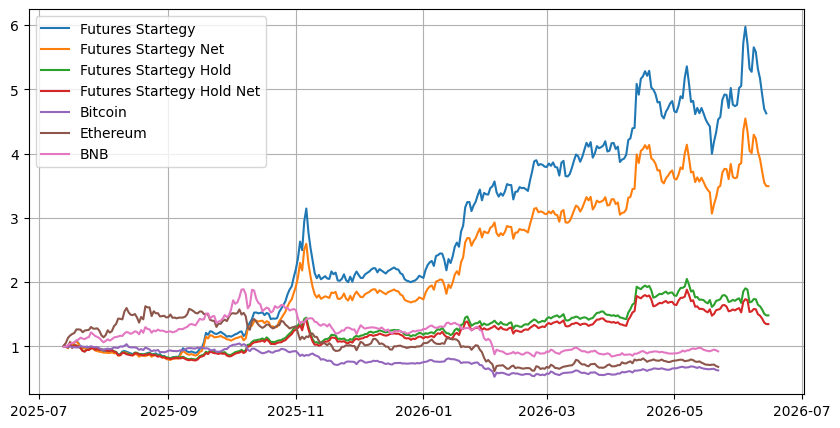

In [62]:
futures_equity = (futures_strat + 1).cumprod()
futures_equity_net = (futures_strat_net + 1).cumprod()
futures_equity_hold = (hold_futures_strat + 1).cumprod()
futures_equity_hold_net = (hold_futures_strat_net + 1).cumprod()


btc = rts['BTC'].reindex(futures_equity.index)
btc = (1 + btc).cumprod()
eth = rts['ETH'].reindex(futures_equity.index)
eth = (1 + eth).cumprod()
bnb = rts['BNB'].reindex(futures_equity.index)
bnb = (1 + bnb).cumprod()

plt.figure(figsize=(10, 5))

plt.plot(futures_equity, label='Futures Startegy')
plt.plot(futures_equity_net, label='Futures Startegy Net')

plt.plot(futures_equity_hold, label='Futures Startegy Hold')
plt.plot(futures_equity_hold_net, label='Futures Startegy Hold Net')

plt.plot(btc, label='Bitcoin')
plt.plot(eth, label='Ethereum')
plt.plot(bnb, label='BNB')

plt.legend()
plt.grid()
plt.show()

In [74]:
API_KEY = os.environ["BNB_KEY"]

headers = {"X-MBX-APIKEY": API_KEY}
resp = requests.get(
    "https://api.binance.com/sapi/v1/margin/allPairs",
    headers=headers,
    timeout=15,
)
info = resp.json()
info

[{'id': 351637150141315861,
  'symbol': 'BNBBTC',
  'base': 'BNB',
  'quote': 'BTC',
  'isMarginTrade': True,
  'isBuyAllowed': True,
  'isSellAllowed': True},
 {'id': 351637923235429141,
  'symbol': 'TRXBTC',
  'base': 'TRX',
  'quote': 'BTC',
  'isMarginTrade': True,
  'isBuyAllowed': True,
  'isSellAllowed': True},
 {'id': 351638112213990165,
  'symbol': 'XRPBTC',
  'base': 'XRP',
  'quote': 'BTC',
  'isMarginTrade': True,
  'isBuyAllowed': True,
  'isSellAllowed': True},
 {'id': 351638524530850581,
  'symbol': 'ETHBTC',
  'base': 'ETH',
  'quote': 'BTC',
  'isMarginTrade': True,
  'isBuyAllowed': True,
  'isSellAllowed': True},
 {'id': 418310092140600180,
  'symbol': 'LINKBTC',
  'base': 'LINK',
  'quote': 'BTC',
  'isMarginTrade': True,
  'isBuyAllowed': True,
  'isSellAllowed': True},
 {'id': 424132564555422744,
  'symbol': 'ADABTC',
  'base': 'ADA',
  'quote': 'BTC',
  'isMarginTrade': True,
  'isBuyAllowed': True,
  'isSellAllowed': True},
 {'id': 434000758724123871,
  'symbol'

In [75]:
margin_pairs = {}
for s in info:
    margin_pairs[s['base']] = s['symbol']

In [76]:
excluded = set(STABLECOINS_HARDCODED) | WRAPPED_TOKENS | stablecoins
margin_candidates = []
for c in coins:
    sym = c["symbol"].upper()
    if sym in excluded:
        continue
    if sym in margin_pairs:
        margin_candidates.append({
            "symbol": sym,
            "binance_margin": margin_pairs[sym],
            "coin_id": c["id"],
            "name": c["name"],
            "rank": c.get("market_cap_rank", 999),
        })
    if len(margin_candidates) >= 100:
        break

In [77]:
margin_filter = [c['binance_margin'] for c in margin_candidates]
margin = []

for symbol in margin_filter:
    resp = binance.get_klines(symbol, source='SPOT', days=365)
    margin.extend(resp)

df_margin = pd.DataFrame(margin)
df_margin['date'] = pd.to_datetime(df_margin["date"])
df_margin

,symbol,date,open,high,low,close,volume_base,volume_usdt,trades
0,BTCUSDC,2025-06-16,105604.30000,108990.04000,104995.80000,106849.84000,4.336802e+03,4.656188e+08,616777
1,BTCUSDC,2025-06-17,106849.84000,107794.00000,103387.27000,104579.73000,5.160201e+03,5.441472e+08,682186
2,BTCUSDC,2025-06-18,104581.78000,105573.46000,103507.15000,104922.02000,3.833342e+03,4.009256e+08,576083
3,BTCUSDC,2025-06-19,104922.02000,105261.42000,103950.00000,104686.01000,2.332440e+03,2.440014e+08,368938
4,BTCUSDC,2025-06-20,104684.02000,106543.98000,102355.11000,103311.99000,4.698636e+03,4.908727e+08,586060
...,...,...,...,...,...,...,...,...,...
34081,ZKUSDC,2026-06-11,0.01028,0.01167,0.01027,0.01111,7.183957e+07,8.019135e+05,4168
34082,ZKUSDC,2026-06-12,0.01112,0.01170,0.01085,0.01148,3.583721e+07,4.004317e+05,2287
34083,ZKUSDC,2026-06-13,0.01151,0.01219,0.01142,0.01150,3.953319e+07,4.672365e+05,3535
34084,ZKUSDC,2026-06-14,0.01151,0.01206,0.01109,0.01177,3.549020e+07,4.095956e+05,3173


In [78]:
df_margin = df_margin[df_margin["symbol"] != "ETCUSDC"]
df_margin = df_margin[df_margin["symbol"] != "ZECUSDC"]

In [79]:
margin_volume = pd.pivot_table(df_margin, values='volume_usdt', index='date', columns='symbol')
margin_px = pd.pivot_table(df_margin, values='close', index='date', columns='symbol')
margin_rts = margin_px.pct_change().shift(-1)

In [80]:
short_sma= margin_volume.rolling(SHORT_SMA).mean()
long_sma = margin_volume.rolling(LONG_SMA).mean()
rvol = short_sma / long_sma

signal_margin = {}

for i, row in rvol.iterrows():

    clean = row.dropna()
    
    if clean.notna().sum() >= 10:
        top = clean.nlargest(5)
        bot = clean.nsmallest(5)

        signal_margin[i] = {
            'top': list(top.index),
            'bot': list(bot.index)
        }

In [81]:
fee_rate = 0.001
margin_strat = {}
margin_strat_net = {}

prev_weights = pd.Series(0, index=margin_rts.columns)

for i, row in margin_rts.iterrows():
    selection = signal_margin.get(i, None)
    
    if selection is not None:
        
        top_symbols = selection['top']
        bot_symbols = selection['bot']
        long = row[top_symbols].mean()
        short = -row[bot_symbols].mean()

        weights = pd.Series(0.0, index=row.index)
        weights_long = weights.copy()

        weights[top_symbols] =  1 / len(top_symbols)
        weights[bot_symbols] = -1 / len(bot_symbols)
        
        gross_return = (weights * row).sum()
        turnover = (weights - prev_weights).abs().sum()
        transaction_cost = turnover * fee_rate
        net_return = gross_return - transaction_cost
        
        portfolio = long + short
        
        margin_strat[i] = portfolio
        margin_strat_net[i] = net_return

        prev_weights = weights
        
margin_strat = pd.Series(margin_strat)
margin_strat_net = pd.Series(margin_strat_net)

In [82]:
margin_strat

2025-07-13    0.004327
2025-07-14   -0.010448
2025-07-15   -0.018248
2025-07-16    0.048738
2025-07-17   -0.059480
                ...   
2026-06-11   -0.020014
2026-06-12    0.014409
2026-06-13   -0.010554
2026-06-14   -0.032467
2026-06-15         NaN
Length: 338, dtype: float64

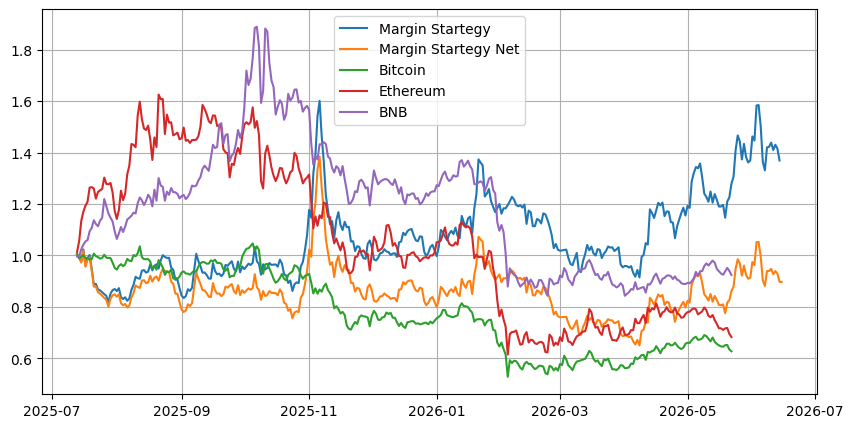

In [83]:
margin_equity = (margin_strat + 1).cumprod()
margin_equity_net = (margin_strat_net + 1).cumprod()
# futures_equity_hold = (hold_futures_strat + 1).cumprod()
# futures_equity_hold_net = (hold_futures_strat_net + 1).cumprod()


btc = rts['BTC'].reindex(futures_equity.index)
btc = (1 + btc).cumprod()
eth = rts['ETH'].reindex(futures_equity.index)
eth = (1 + eth).cumprod()
bnb = rts['BNB'].reindex(futures_equity.index)
bnb = (1 + bnb).cumprod()

plt.figure(figsize=(10, 5))

plt.plot(margin_equity, label='Margin Startegy')
plt.plot(margin_equity_net, label='Margin Startegy Net')

# plt.plot(futures_equity_hold, label='Futures Startegy Hold')
# plt.plot(futures_equity_hold_net, label='Futures Startegy Hold Net')

plt.plot(btc, label='Bitcoin')
plt.plot(eth, label='Ethereum')
plt.plot(bnb, label='BNB')

plt.legend()
plt.grid()
plt.show()